# Step 0: Setup and Data Loading

In this notebook, I am going to build a complete and research-oriented feature engineering pipeline for the Ames Housing dataset using proper machine learning practices.

The primary objective of this notebook is to transform the raw housing data into a clean, modeling-ready dataset that can be used for reliable regression modeling and house price prediction.

This notebook follows a structured feature engineering workflow based on:

- exploratory data analysis (EDA),
- dataset-specific domain understanding,
- leakage-safe preprocessing principles,
- cross-validation-aware feature engineering,
- and validated machine learning practices.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep"
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

RANDOM_STATE = 42

OUTPUT_DIR = Path("prepared_data")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Setup complete.")


Setup complete.


In [2]:
# Try common dataset locations.
# Change DATA_DIR manually if needed.

candidate_dirs = [
    Path("../Data"),
    Path("./Data"),
    Path("./data"),
    Path("."),
    Path("/mnt/data"),
]

def find_dataset_file(filenames, candidate_dirs):
    """
    Search common project folders for a dataset file.

    filenames can be a string or a list of possible names.
    This keeps the notebook compatible with both train.csv and train(2).csv.
    """
    if isinstance(filenames, str):
        filenames = [filenames]

    checked_paths = []
    for data_dir in candidate_dirs:
        for filename in filenames:
            file_path = data_dir / filename
            checked_paths.append(file_path)
            if file_path.exists():
                return file_path

    raise FileNotFoundError(
        "Could not find any of these files: "
        + ", ".join(filenames)
        + "\nChecked locations:\n"
        + "\n".join(str(p) for p in checked_paths)
    )

train_path = find_dataset_file(["train.csv", "train(2).csv"], candidate_dirs)
test_path = find_dataset_file("test.csv", candidate_dirs)

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

# Keep IDs safely before dropping Id later.
train_ids = train["Id"].copy() if "Id" in train.columns else pd.Series(np.arange(len(train)), name="Id")
test_ids = test["Id"].copy() if "Id" in test.columns else pd.Series(np.arange(len(test)), name="Id")

print(f"Train path: {train_path}")
print(f"Test path: {test_path}")
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")


Train path: ..\Data\train.csv
Test path: ..\Data\test.csv
Train shape: (1460, 81)
Test shape: (1459, 80)


# 1 : Remove Canonical Outliers (train only)

### Which rows

Two rows have `GrLivArea` above 4000 with `SalePrice` below $200,000.  
All other houses with `GrLivArea` above 4000 sell for above $700,000.  
These rows are confirmed anomalies — not valid market observations.  
They are likely distressed sales or related-party transactions.

### Decision

Remove both rows from train before any other step.  
Do not apply this filter to test.


In [3]:
clean_train = train.copy()

In [4]:
# Find canonical outliers
outliers = clean_train[
    (clean_train["GrLivArea"] > 4000) &
    (clean_train["SalePrice"] < 200000)
]

print(outliers[["GrLivArea", "SalePrice"]])

      GrLivArea  SalePrice
523        4676     184750
1298       5642     160000


> remove 523th and 1298th row

In [5]:
# Remove canonical outliers from training data
canonical_outlier_mask = (
    (clean_train["GrLivArea"] > 4000) &
    (clean_train["SalePrice"] < 200000)
)

removed_outlier_ids = clean_train.loc[canonical_outlier_mask, "Id"].tolist() if "Id" in clean_train.columns else []
removed_outlier_indices = clean_train.index[canonical_outlier_mask].tolist()

clean_train = clean_train.loc[~canonical_outlier_mask].reset_index(drop=True)

print(f"Original train shape : {train.shape}")
print(f"Clean train shape    : {clean_train.shape}")
print(f"Removed outlier indices: {removed_outlier_indices}")
print(f"Removed outlier Ids: {removed_outlier_ids}")


Original train shape : (1460, 81)
Clean train shape    : (1458, 81)
Removed outlier indices: [523, 1298]
Removed outlier Ids: [524, 1299]


# 2: Target Transformation

**we will use log1p transformation on target column**

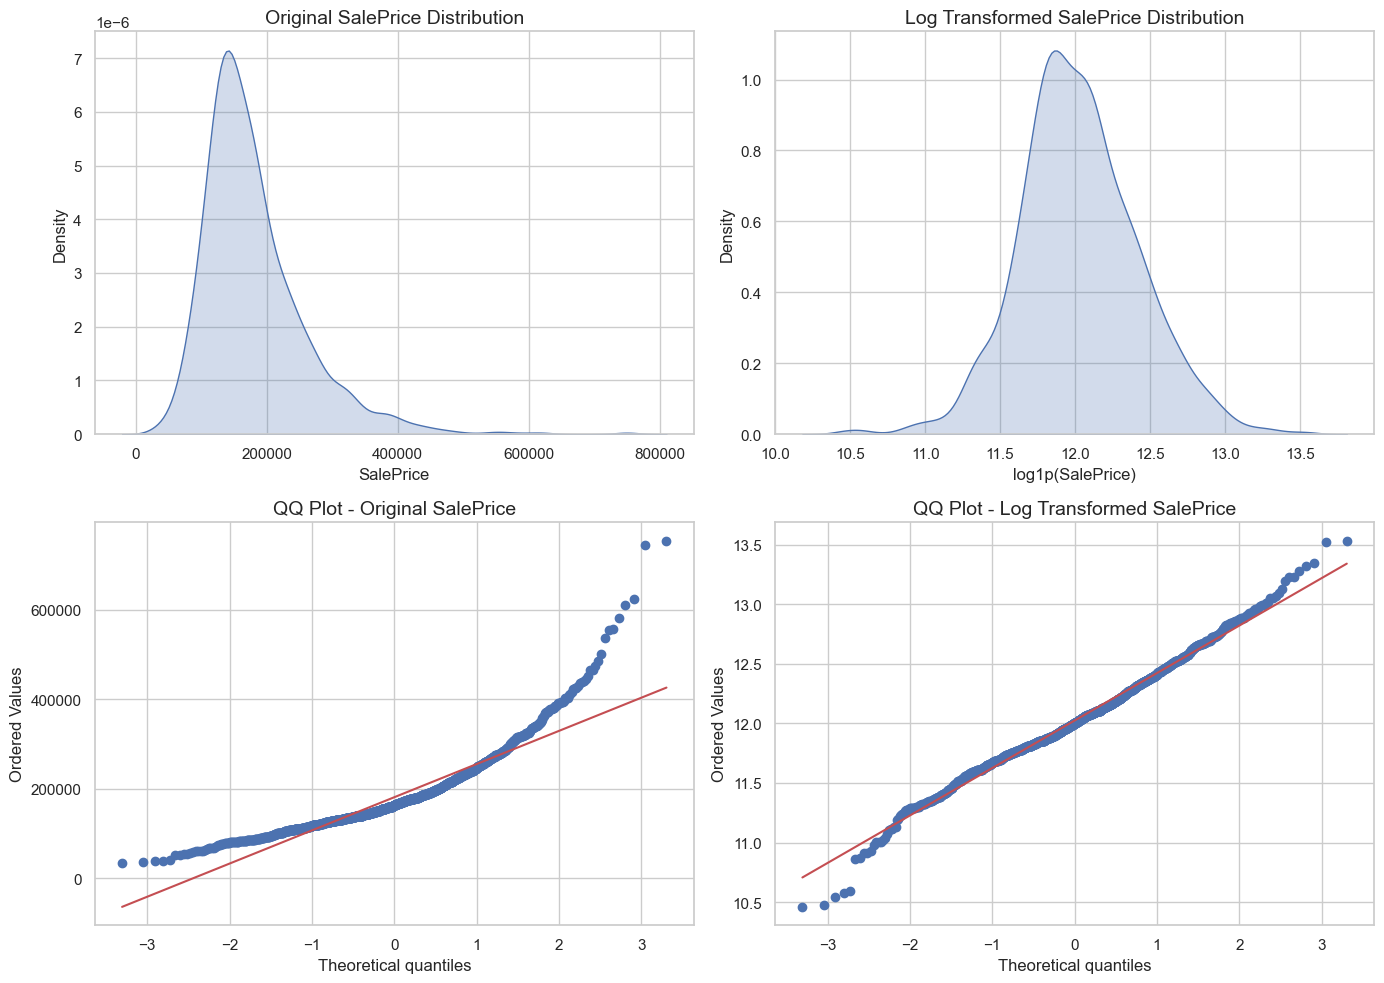

In [6]:
# SalePrice vs Log(SalePrice) Distribution Comparison
# KDE Plot + QQ Plot


from scipy.stats import probplot

# Create log-transformed target
clean_train["SalePrice_log"] = np.log1p(clean_train["SalePrice"])

# Create Figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# KDE Plot - Original SalePrice
sns.kdeplot(
    clean_train["SalePrice"],
    fill=True,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Original SalePrice Distribution")
axes[0, 0].set_xlabel("SalePrice")

# KDE Plot - Log Transformed SalePrice
sns.kdeplot(
    clean_train["SalePrice_log"],
    fill=True,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Log Transformed SalePrice Distribution")
axes[0, 1].set_xlabel("log1p(SalePrice)")

# QQ Plot - Original SalePrice
probplot(
    clean_train["SalePrice"],
    dist="norm",
    plot=axes[1, 0]
)

axes[1, 0].set_title("QQ Plot - Original SalePrice")

# QQ Plot - Log Transformed SalePrice
probplot(
    clean_train["SalePrice_log"],
    dist="norm",
    plot=axes[1, 1]
)

axes[1, 1].set_title("QQ Plot - Log Transformed SalePrice")

# Layout
plt.tight_layout()
plt.show()

> yes its pretty cool , saleprice is following now normal distribution

# 3. Train-Test Combine

In [7]:
# Store target separately
y_original = clean_train["SalePrice"].copy()
y = clean_train["SalePrice_log"].copy()

# Remove target column BEFORE combining
# IMPORTANT: also remove any derived target columns like SalePrice_log if it exists
train_features = clean_train.drop(
    columns=["SalePrice", "SalePrice_log"],
    errors="ignore"
)

# Save train row count for later split-back
n_train = train_features.shape[0]

print(f"Number of train rows : {n_train}")
print(f"Number of test rows  : {test.shape[0]}")

# Combine Train and Test (ONLY features)
full_data = pd.concat(
    [train_features, test],
    axis=0,
    ignore_index=True
)

print("\nCombined dataframe shape:")
print(full_data.shape)


Number of train rows : 1458
Number of test rows  : 1459

Combined dataframe shape:
(2917, 80)


In [8]:
full_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0000,Gd,TA,PConc,Gd,TA,No,GLQ,706.0000,Unf,0.0000,150.0000,856.0000,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0000,0.0000,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0000,RFn,2.0000,548.0000,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0000,Unf,0.0000,284.0000,1262.0000,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0000,1.0000,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0000,RFn,2.0000,460.0000,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0000,Unf,0.0000,434.0000,920.0000,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0000,0.0000,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0000,RFn,2.0000,608.0000,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0000,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0000,Unf,0.0000,540.0000,756.0000,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0000,0.0000,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0000,Unf,3.0000,642.0000,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0000,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0000,Unf,0.0000,490.0000,1145.0000,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0000,0.0000,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0000,RFn,3.0000,836.0000,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


# 4. Fix known data error

## 4.1  GarageYrBlt Typo in Test Set

One test observation has `GarageYrBlt = 2207`.  
This is a confirmed keystroke error — the value should be 2007.  
If uncorrected, any age feature derived from this value will be wildly wrong.

| Feature | Problem | Correct action |
|---|---|---|
| `GarageYrBlt` | One test value = 2207 (impossible future year) | Replace with `YearBuilt` of the same row |

In [9]:
garage_typo_mask = full_data["GarageYrBlt"] == 2207

if garage_typo_mask.any():
    full_data.loc[garage_typo_mask, "GarageYrBlt"] = full_data.loc[garage_typo_mask, "YearBuilt"]
    print(f"Fixed GarageYrBlt typo rows: {garage_typo_mask.sum()}")
else:
    print("No GarageYrBlt = 2207 typo found.")


Fixed GarageYrBlt typo rows: 1


In [10]:
full_data["Id"] == 2590

0       False
1       False
2       False
3       False
4       False
        ...  
2912    False
2913    False
2914    False
2915    False
2916    False
Name: Id, Length: 2917, dtype: bool

In [11]:
full_data.loc[full_data["Id"] == 2590, "GarageYrBlt"]

2587   1987.0000
Name: GarageYrBlt, dtype: float64

>perfectly replaced

### 4.2 — YearRemodAdd After YrSold

One train row has `YearRemodAdd = 2008` but `YrSold = 2007`.  
A house cannot be remodeled after it was sold.  
This produces a negative `RemodAge` if left uncorrected.

| Feature | Problem | Correct action |
|---|---|---|
| `YearRemodAdd` | One row has value after `YrSold` | Cap `YearRemodAdd` to `YrSold` for all rows |

### Important ordering rule

`YearRemodAdd` must be corrected **before** deriving `IsRemodeled` and `RemodAge`.  
If the order is reversed, `IsRemodeled` will be computed from the wrong source value.


In [12]:
# full_data.loc[(full_data['YearRemodAdd'] == 2008) &(full_data['YrSold'] == 2007) , "YearRemodAdd"]  = full_data.loc[(full_data['YearRemodAdd'] == 2008) &(full_data['YrSold'] == 2007) , "YrSold"] 

In [13]:
remodel_after_sold_mask = full_data["YearRemodAdd"] > full_data["YrSold"]

if remodel_after_sold_mask.any():
    full_data.loc[remodel_after_sold_mask, "YearRemodAdd"] = full_data.loc[remodel_after_sold_mask, "YrSold"]
    print(f"Fixed YearRemodAdd > YrSold rows: {remodel_after_sold_mask.sum()}")
else:
    print("No YearRemodAdd > YrSold issue found.")


Fixed YearRemodAdd > YrSold rows: 2


> Here i have used 2 method first one is manual second one is automate

> perfectly solved 

## 5. Meaningful Missing Value Handling — Categorical

### Rule

Do not mode-fill any of these features.  
Their missing values carry structural information: the house does not have the facility.

### Fill table

| Feature group | Features | Fill value |
|---|---|---|
| Garage-related | `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond` | `NoGarage` |
| Basement-related | `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2` | `NoBasement` |
| Fireplace | `FireplaceQu` | `NoFireplace` |
| Pool | `PoolQC` | `NoPool` |
| Fence | `Fence` | `NoFence` |
| Alley | `Alley` | `NoAlley` |
| Misc feature | `MiscFeature` | `None` |


## 5.1 Garage Related missing value handling

In [14]:
garage_cols = [
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond"
]

In [15]:
full_data[garage_cols] = full_data[garage_cols].fillna("NoGarage")

In [16]:
full_data["HasGarage"] = (full_data["GarageType"] != "NoGarage").astype(int)

## 5.2 Basement Realted missing value handling

In [17]:
bsmt_cols = [
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

In [18]:
full_data[bsmt_cols] = full_data[bsmt_cols].fillna("NoBasement")

## 5.3 Fireplace,Pool,Fence,Alley,Misc feature Related missing value handling

In [19]:
fireplace_cols = ["FireplaceQu"]
pool_cols = ["PoolQC"]
fence_cols = ["Fence"]
alley_cols = ["Alley"]
misc_cols = ["MiscFeature"]

In [20]:
full_data[fireplace_cols] = full_data[fireplace_cols].fillna("NoFireplace")
full_data[pool_cols] = full_data[pool_cols].fillna("NoPool")
full_data[fence_cols] = full_data[fence_cols].fillna("NoFence")
full_data[alley_cols] = full_data[alley_cols].fillna("NoAlley")
full_data[misc_cols] = full_data[misc_cols].fillna("None")

# 6. Test set missing value handling

### 6.1 Numeric features — fill with 0

These are all absence-type missings: a single row is missing basement or garage values because the house has no such facility.

| Feature | Fill value | Reason |
|---|---|---|
| `BsmtFullBath` | 0 | No basement |
| `BsmtHalfBath` | 0 | No basement |
| `BsmtFinSF1` | 0 | No basement |
| `BsmtFinSF2` | 0 | No basement |
| `BsmtUnfSF` | 0 | No basement |
| `TotalBsmtSF` | 0 | No basement |
| `GarageCars` | 0 | No garage |
| `GarageArea` | 0 | No garage |


In [21]:
bsmt_num_cols = [
    "BsmtFullBath",
    "BsmtHalfBath",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF"
]

garage_num_cols = [
    "GarageCars",
    "GarageArea"
]

In [22]:
full_data[bsmt_num_cols] = full_data[bsmt_num_cols].fillna(0)
full_data[garage_num_cols] = full_data[garage_num_cols].fillna(0)

### 6.2 Categorical features — fill with mode or documented default

| Feature | Fill value | Reason |
|---|---|---|
| `MSZoning` | Mode from train | 4 missing; RL dominates train |
| `Exterior1st` | Mode from train | 1 missing |
| `Exterior2nd` | Mode from train | 1 missing |
| `KitchenQual` | Mode from train | 1 missing; TA dominates |
| `SaleType` | Mode from train | 1 missing; WD dominates |
| `Electrical` | Mode from train | 1 missing; SBrkr dominates |
| `Functional` | `Typ` | Ames data dictionary default for missing |


In [23]:
mode_cols = [
    "MSZoning",
    "Exterior1st",
    "Exterior2nd",
    "KitchenQual",
    "SaleType",
    "Electrical"
]

fixed_default_cols = {
    "Functional": "Typ"
}

##### Fill mode-based columns (from TRAIN only)

In [24]:
for col in mode_cols:
    if col in full_data.columns:
        mode_value = clean_train[col].mode(dropna=True)[0]
        full_data[col] = full_data[col].fillna(mode_value)
        print(f"{col}: filled missing with train mode = {mode_value}")


MSZoning: filled missing with train mode = RL
Exterior1st: filled missing with train mode = VinylSd
Exterior2nd: filled missing with train mode = VinylSd
KitchenQual: filled missing with train mode = TA
SaleType: filled missing with train mode = WD
Electrical: filled missing with train mode = SBrkr


##### Fill fixed default columns

In [25]:
for col, val in fixed_default_cols.items():
    if col in full_data.columns:
        full_data[col] = full_data[col].fillna(val)
        print(f"{col}: filled missing with documented default = {val}")


Functional: filled missing with documented default = Typ


## 7. LotFrontage Imputation

### Plan

Impute missing `LotFrontage` using the median value of the same `Neighborhood`.

### Reason

Lot frontage depends on local street geometry and zoning.  
Neighborhood-wise medians produce more accurate imputations than a global median.

### Critical leakage rule

Neighborhood medians must be computed from train rows only.  
Computing them from the combined dataframe allows test-row values to influence train imputation.  
This is a data leakage that inflates cross-validation score.


In [26]:
# train-based median
lot_median_by_neigh = clean_train.groupby("Neighborhood")["LotFrontage"].median()
lot_global_median = clean_train["LotFrontage"].median()

print("LotFrontage train global median:", lot_global_median)


LotFrontage train global median: 69.0


In [27]:
def fill_lot_frontage(row):
    if pd.isnull(row["LotFrontage"]):
        # Use train neighborhood median when available.
        # If a test neighborhood is unseen or its median is missing, use train global median.
        return lot_median_by_neigh.get(row["Neighborhood"], lot_global_median)
    else:
        return row["LotFrontage"]


In [28]:
full_data["LotFrontage"] = full_data.apply(fill_lot_frontage, axis=1)
full_data["LotFrontage"] = full_data["LotFrontage"].fillna(lot_global_median)

print("LotFrontage missing after imputation:", full_data["LotFrontage"].isna().sum())


LotFrontage missing after imputation: 0



## 8. MasVnrType and MasVnrArea Disambiguation

### Why this section exists

`MasVnrType` has 872 missing values — the largest non-facility gap in the dataset.  
The original plan only said "fill with None" without distinguishing two different missing cases.

### Two cases

| Case | Condition | Correct action |
|---|---|---|
| Case A | `MasVnrType` missing AND `MasVnrArea` missing | Both indicate no veneer — fill `MasVnrType` with `None`, fill `MasVnrArea` with 0 |
| Case B | `MasVnrType` missing BUT `MasVnrArea` is greater than 0 | Veneer exists but type is unknown — fill `MasVnrType` with mode of veneer houses (train only) |

## 8.1 Case A — No veneer exists

In [29]:
mask_a = (
    full_data["MasVnrType"].isna() &
    (full_data["MasVnrArea"].fillna(0) == 0)
)

full_data.loc[mask_a, "MasVnrType"] = "None"
full_data.loc[mask_a, "MasVnrArea"] = 0

## 8.2 Case B — Veneer exists but type missing

In [30]:
mask_b = (
    full_data["MasVnrType"].isna() &
    (full_data["MasVnrArea"] > 0)
)

mode_veneer = clean_train["MasVnrType"].mode(dropna=True)[0]

full_data.loc[mask_b, "MasVnrType"] = mode_veneer

# Final safety: no remaining veneer missing values
full_data["MasVnrType"] = full_data["MasVnrType"].fillna("None")
full_data["MasVnrArea"] = full_data["MasVnrArea"].fillna(0)

print("MasVnrType missing:", full_data["MasVnrType"].isna().sum())
print("MasVnrArea missing:", full_data["MasVnrArea"].isna().sum())


MasVnrType missing: 0
MasVnrArea missing: 0


## 9. Drop Near-Constant Features

### Features to drop

| Feature | Reason |
|---|---|
| `Utilities` | 1459 of 1460 train rows are `AllPub`. Encoding produces a dummy that is 1 for exactly one training row and 0 for all test rows. Pure noise. |
| `Id` | Identifier column. Correlation with `SalePrice` is −0.02. Carries no predictive information. |

### Decision

Drop both features from the combined dataframe before any encoding step.


In [31]:
full_data = full_data.drop(columns=["Utilities", "Id"], errors="ignore")

In [32]:
full_data.shape

(2917, 79)


## 10. Type Conversions

### MSSubClass

`MSSubClass` stores building class codes as integers.  
It is not a continuous numeric variable.  
Convert to string so it will be treated as categorical in encoding steps.

### MoSold and YrSold

Do not convert `MoSold` or `YrSold` to dummy variables.  
This would add approximately 15 near-useless columns to a 1460-row dataset.

| Model type | Recommended treatment |
|---|---|
| Tree models (XGBoost, LightGBM) | Keep as raw integers — trees handle discrete numerics correctly |
| Linear models (Lasso, Ridge) | Use cyclic encoding in the interaction features step |


## 10.1 Step 1 — MSSubClass (IMPORTANT)

In [33]:
full_data["MSSubClass"] = full_data["MSSubClass"].astype(str)

In [34]:
full_data['MSSubClass']

0        60
1        20
2        60
3        70
4        60
       ... 
2912    160
2913    160
2914     20
2915     85
2916     60
Name: MSSubClass, Length: 2917, dtype: object

## 10.2 — MoSold and YrSold

### Option A: Tree models (most common in your project

In [35]:
# do nothing

### Option B: Linear models (Ridge/Lasso)

In [36]:
full_data["MoSold_sin"] = np.sin(2 * np.pi * full_data["MoSold"] / 12)
full_data["MoSold_cos"] = np.cos(2 * np.pi * full_data["MoSold"] / 12)

In [37]:
full_data["YrSold"] = full_data["YrSold"]  # keep as numeric

## 11. Ordinal Encoding 

Ordinal features must preserve their rank order.  
Use explicit integer maps — do not use automatic label encoders which assign arbitrary order.

### 11.1 — Quality / Condition Features 
Standard quality/condition scale applies to 10 features:

| Level | Integer value |
|---|---|
| No facility / missing | 0 |
| Po (Poor) | 1 |
| Fa (Fair) | 2 |
| TA (Typical/Average) | 3 |
| Gd (Good) | 4 |
| Ex (Excellent) | 5 |

Apply this map to:

```text
ExterQual
ExterCond
BsmtQual
BsmtCond
HeatingQC
KitchenQual
FireplaceQu
GarageQual
GarageCond
PoolQC
```

In [38]:
quality_map = {
    "NoPool": 0,
    "NoGarage": 0,
    "NoBasement": 0,
    "NoFireplace": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}
quality_cols = [
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
    "PoolQC"
]

In [39]:
for col in quality_cols:
    full_data[col] = full_data[col].map(quality_map)

# Safety check for unmapped/missing ordinal quality values
quality_missing = full_data[quality_cols].isna().sum()
quality_missing = quality_missing[quality_missing > 0]

if len(quality_missing) > 0:
    print("Missing/unmapped quality values found:")
    print(quality_missing)
    # Use 0 only for genuinely absent facility-style columns, and train median for others.
    absent_ok_cols = ["BsmtQual", "BsmtCond", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"]
    for col in quality_missing.index:
        if col in absent_ok_cols:
            full_data[col] = full_data[col].fillna(0)
        else:
            train_median = full_data.iloc[:n_train][col].median()
            full_data[col] = full_data[col].fillna(train_median)
else:
    print("All quality columns mapped successfully.")


All quality columns mapped successfully.


In [40]:
print(full_data["PoolQC"].unique())
print(full_data['ExterCond'].unique())

[0 5 2 4]
[3 4 2 1 5]


### 11.2 — Other Ordinal Features

| Feature | Order (low to high) |
|---|---|
| `BsmtExposure` | `NoBasement < No < Mn < Av < Gd` |
| `BsmtFinType1` | `NoBasement < Unf < LwQ < Rec < BLQ < ALQ < GLQ` |
| `BsmtFinType2` | `NoBasement < Unf < LwQ < Rec < BLQ < ALQ < GLQ` |
| `GarageFinish` | `NoGarage < Unf < RFn < Fin` |
| `PavedDrive` | `N < P < Y` |
| `LandSlope` | `Sev < Mod < Gtl` |
| `Functional` | `Sal < Sev < Maj2 < Maj1 < Mod < Min2 < Min1 < Typ` |


In [41]:
bsmt_exposure_map = {
    "NoBasement": 0,
    "No": 1,
    "Mn": 2,
    "Av": 3,
    "Gd": 4
}

bsmt_fin_map = {
    "NoBasement": 0,
    "Unf": 1,
    "LwQ": 2,
    "Rec": 3,
    "BLQ": 4,
    "ALQ": 5,
    "GLQ": 6
}

garage_finish_map = {
    "NoGarage": 0,
    "Unf": 1,
    "RFn": 2,
    "Fin": 3
}

paved_drive_map = {
    "N": 0,
    "P": 1,
    "Y": 2
}

land_slope_map = {
    "Sev": 0,
    "Mod": 1,
    "Gtl": 2
}

functional_map = {
    "Sal": 0,
    "Sev": 1,
    "Maj2": 2,
    "Maj1": 3,
    "Mod": 4,
    "Min2": 5,
    "Min1": 6,
    "Typ": 7
}

In [42]:
full_data["BsmtExposure"] = full_data["BsmtExposure"].map(bsmt_exposure_map)

full_data["BsmtFinType1"] = full_data["BsmtFinType1"].map(bsmt_fin_map)

full_data["BsmtFinType2"] = full_data["BsmtFinType2"].map(bsmt_fin_map)

full_data["GarageFinish"] = full_data["GarageFinish"].map(garage_finish_map)

full_data["PavedDrive"] = full_data["PavedDrive"].map(paved_drive_map)

full_data["LandSlope"] = full_data["LandSlope"].map(land_slope_map)

full_data["Functional"] = full_data["Functional"].map(functional_map)

ordinal_cols = [
    "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "GarageFinish", "PavedDrive", "LandSlope", "Functional"
]

ordinal_missing = full_data[ordinal_cols].isna().sum()
ordinal_missing = ordinal_missing[ordinal_missing > 0]

if len(ordinal_missing) > 0:
    print("Missing/unmapped ordinal values found:")
    print(ordinal_missing)
    zero_absent_cols = ["BsmtExposure", "BsmtFinType1", "BsmtFinType2", "GarageFinish"]
    for col in ordinal_missing.index:
        if col in zero_absent_cols:
            full_data[col] = full_data[col].fillna(0)
        else:
            train_median = full_data.iloc[:n_train][col].median()
            full_data[col] = full_data[col].fillna(train_median)
else:
    print("All ordinal columns mapped successfully.")


All ordinal columns mapped successfully.


In [43]:
full_data["BsmtExposure"].unique()

array([1, 4, 2, 3, 0])

In [44]:
full_data["BsmtFinType1"].unique()

array([6, 5, 1, 3, 4, 0, 2])


### 11.3 — LotShape: Treat as Nominal

Original plan ordinal-encoded `LotShape` as `IR3 < IR2 < IR1 < Reg`.  
This is incorrect.

Data-verified median prices:

| LotShape | Median SalePrice |
|---|---|
| IR2 | $221,000 |
| IR3 | $203,570 |
| IR1 | $189,000 |
| Reg | $146,000 |

Irregular lots sell for more than regular lots in this dataset.  
The relationship is not monotone and not consistent with a single ordinal direction.  
The underlying cause is that irregular lots cluster in premium neighborhoods.

**Decision:** Treat `LotShape` as nominal. Leave it for one-hot encoding in step 20.



### 11.4 — Fence: Treat as Nominal

Original plan ordinal-encoded `Fence` as `NoFence < MnWw < GdWo < MnPrv < GdPrv`.  
This is incorrect.

Data-verified median prices:

| Fence | Median SalePrice |
|---|---|
| GdPrv | $167,500 |
| GdWo | $138,750 |
| MnPrv | $137,450 |
| MnWw | $130,000 |

The ordering is non-monotone.  
Fence type appears to be a neighborhood proxy, not a quality signal.

**Decision:** Treat `Fence` as nominal. Leave it for one-hot encoding in step 20.

### Decision

- Ordinal encode only features with a confirmed and correct directional order.
- Do not one-hot encode ordinal features — this wastes the rank information.
- After encoding, all ordinal columns become integers. Any unmapped value should become 0.


In [45]:
full_data.shape

(2917, 81)

In [46]:
full_data['Street'].isna().sum()

np.int64(0)

In [ ]:

# Clean string values first


full_data["CentralAir"] = full_data["CentralAir"].astype(str).str.strip()
full_data["Street"] = full_data["Street"].astype(str).str.strip()
# Binary Encoding


full_data["CentralAir"] = full_data["CentralAir"].map({
    "Y": 1,
    "N": 0
})

full_data["Street"] = full_data["Street"].map({
    "Pave": 1,
    "Grvl": 0
})

# =========================
# Engineered Flags
# =========================

full_data["HasGarage"] = (
    full_data["GarageType"] != "NoGarage"
).astype(int)

full_data["HasBasement"] = (
    full_data["BsmtQual"] != "NoBasement"
).astype(int)

full_data["HasPool"] = (
    full_data["PoolQC"] != "NoPool"
).astype(int)

# =========================
# Check missing values
# =========================

print(full_data["CentralAir"].isna().sum())
print(full_data["Street"].isna().sum())

0
0


## 13. Core Area Features

### 13.1 — Total Square Footage

| New feature | Formula | Priority |
|---|---|---|
| `TotalSF` | `TotalBsmtSF + 1stFlrSF + 2ndFlrSF` | High |
| `TotalFinishedSF` | `1stFlrSF + 2ndFlrSF + BsmtFinSF1 + BsmtFinSF2` | Medium |
| `TotalPorchSF` | `OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch` | Medium |
| `TotalOutdoorSF` | `WoodDeckSF + OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch + PoolArea` | Medium |

### Important correction — TotalLivingSF removed

`TotalLivingSF` was defined as `GrLivArea + TotalBsmtSF`.  
Since `GrLivArea = 1stFlrSF + 2ndFlrSF` by definition in this dataset, `TotalLivingSF` is mathematically identical to `TotalSF`.  
Keeping both inflates feature importance, creates a perfect duplicate, and confuses model selection.

**Decision:** Remove `TotalLivingSF` from the plan entirely. Use `TotalSF` only.


In [48]:
# =========================
# Core Area Features
# =========================

full_data["TotalSF"] = (
    full_data["TotalBsmtSF"] +
    full_data["1stFlrSF"] +
    full_data["2ndFlrSF"]
)

full_data["TotalFinishedSF"] = (
    full_data["1stFlrSF"] +
    full_data["2ndFlrSF"] +
    full_data["BsmtFinSF1"] +
    full_data["BsmtFinSF2"]
)

full_data["TotalPorchSF"] = (
    full_data["OpenPorchSF"] +
    full_data["EnclosedPorch"] +
    full_data["3SsnPorch"] +
    full_data["ScreenPorch"]
)

full_data["TotalOutdoorSF"] = (
    full_data["WoodDeckSF"] +
    full_data["OpenPorchSF"] +
    full_data["EnclosedPorch"] +
    full_data["3SsnPorch"] +
    full_data["ScreenPorch"] +
    full_data["PoolArea"]
)

# =========================
# Remove duplicate feature
# =========================

if "TotalLivingSF" in full_data.columns:
    full_data.drop(columns=["TotalLivingSF"], inplace=True)

In [49]:
full_data.shape

(2917, 87)


## 14. Bathroom and Count Features

| New feature | Formula | Priority |
|---|---|---|
| `TotalBath` | `FullBath + 0.5 × HalfBath + BsmtFullBath + 0.5 × BsmtHalfBath` | High |
| `TotalFullBath` | `FullBath + BsmtFullBath` | Medium |
| `TotalHalfBath` | `HalfBath + BsmtHalfBath` | Medium |
| `BathPerBedroom` | `TotalBath / BedroomAbvGr` | Medium |
| `RoomPerBedroom` | `TotRmsAbvGrd / BedroomAbvGr` | Medium |

### Division guard — BathPerBedroom and RoomPerBedroom

6 rows in train have `BedroomAbvGr = 0`.  
The denominator is zero for these rows.

Original plan rule was:

```text
BathPerBedroom = TotalBath / BedroomAbvGr.replace(0, NaN).fillna(0)
```

This is circular: replacing 0 with NaN and then filling NaN with 0 gives the exact same result as doing nothing.  
A house with 0 bedrooms and 2 bathrooms would get `BathPerBedroom = 0`, which is a worse representation than the actual ratio.

**Correct decision:**  
For zero-bedroom rows, fill `BathPerBedroom` with the median of the ratio computed on all non-zero-bedroom rows.  
Apply the same logic to `RoomPerBedroom`.


## 14. Bathroom and Count Features


### 14.1 - Total Bathroom Features

| New feature | Formula | Priority |
|---|---|---|
| `TotalBath` | `FullBath + 0.5 × HalfBath + BsmtFullBath + 0.5 × BsmtHalfBath` | High |
| `TotalFullBath` | `FullBath + BsmtFullBath` | Medium |
| `TotalHalfBath` | `HalfBath + BsmtHalfBath` | Medium |

### Division Guards for BathPerBedroom and RoomPerBedroom

**Important:** 6 rows have `BedroomAbvGr = 0`, which would cause division by zero.

**Solution:** For zero-bedroom rows, use median ratio computed on non-zero-bedroom rows only.


In [50]:
# =========================
# Total Bathroom Features
# =========================

full_data["TotalBath"] = (
    full_data["FullBath"] + 
    0.5 * full_data["HalfBath"] + 
    full_data["BsmtFullBath"] + 
    0.5 * full_data["BsmtHalfBath"]
)

full_data["TotalFullBath"] = (
    full_data["FullBath"] + 
    full_data["BsmtFullBath"]
)

full_data["TotalHalfBath"] = (
    full_data["HalfBath"] + 
    full_data["BsmtHalfBath"]
)

print("✓ Total bathroom features created")
print(full_data[["TotalBath", "TotalFullBath", "TotalHalfBath"]].describe())


✓ Total bathroom features created
       TotalBath  TotalFullBath  TotalHalfBath
count  2917.0000      2917.0000      2917.0000
mean      2.2168         1.9962         0.4412
std       0.8069         0.7534         0.5466
min       1.0000         0.0000         0.0000
25%       1.5000         1.0000         0.0000
50%       2.0000         2.0000         0.0000
75%       2.5000         2.0000         1.0000
max       7.0000         6.0000         4.0000


### 14.2 - Ratio Features with Division Guards

In [51]:
# ================================================
# BathPerBedroom and RoomPerBedroom with Guards
# ================================================

# Compute fallback medians on TRAIN ONLY
train_ratio_source = full_data.iloc[:n_train].copy()
train_with_beds = train_ratio_source[train_ratio_source["BedroomAbvGr"] > 0].copy()

train_with_beds["TotalBath_temp"] = (
    train_with_beds["FullBath"] + 
    0.5 * train_with_beds["HalfBath"] + 
    train_with_beds["BsmtFullBath"] + 
    0.5 * train_with_beds["BsmtHalfBath"]
)

median_bath_per_bed = (
    train_with_beds["TotalBath_temp"] / train_with_beds["BedroomAbvGr"]
).median()

median_room_per_bed = (
    train_with_beds["TotRmsAbvGrd"] / train_with_beds["BedroomAbvGr"]
).median()

print(f"Median BathPerBedroom (train, non-zero bedrooms): {median_bath_per_bed:.4f}")
print(f"Median RoomPerBedroom (train, non-zero bedrooms): {median_room_per_bed:.4f}")

# Create ratio features with vectorized division guards
total_bath_series = (
    full_data["FullBath"] + 
    0.5 * full_data["HalfBath"] + 
    full_data["BsmtFullBath"] + 
    0.5 * full_data["BsmtHalfBath"]
)

full_data["BathPerBedroom"] = np.where(
    full_data["BedroomAbvGr"] > 0,
    total_bath_series / full_data["BedroomAbvGr"],
    median_bath_per_bed
)

full_data["RoomPerBedroom"] = np.where(
    full_data["BedroomAbvGr"] > 0,
    full_data["TotRmsAbvGrd"] / full_data["BedroomAbvGr"],
    median_room_per_bed
)

print("\n✓ Ratio features created with division guards")
print(f"BathPerBedroom - No inf/NaN: {np.isfinite(full_data['BathPerBedroom']).all()}")
print(f"RoomPerBedroom - No inf/NaN: {np.isfinite(full_data['RoomPerBedroom']).all()}")


Median BathPerBedroom (train, non-zero bedrooms): 0.7500
Median RoomPerBedroom (train, non-zero bedrooms): 2.3333

✓ Ratio features created with division guards
BathPerBedroom - No inf/NaN: True
RoomPerBedroom - No inf/NaN: True


## 15. Presence/Absence Flags


Facility presence flags indicate whether a house has a certain feature or not.
These are derived from the categorical features we filled earlier.

| Feature | Derived from | Logic |
|---|---|---|
| `HasGarage` | `GarageType` | ≠ "NoGarage" |
| `HasBasement` | `BsmtQual` | ≠ "NoBasement" (now ordinal ≠ 0) |
| `HasFireplace` | `FireplaceQu` | ≠ "NoFireplace" (now ordinal ≠ 0) |
| `HasPool` | `PoolQC` | ≠ "NoPool" (now ordinal ≠ 0) |
| `HasPorch` | `OpenPorchSF` | > 0 |
| `HasWoodDeck` | `WoodDeckSF` | > 0 |
| `HasMasVnr` | `MasVnrArea` | > 0 |


In [ ]:
# Note: Most ordinal columns are now integers (0-5 range)
# NoBasement/NoPool/NoFireplace = 0, so > 0 means facility exists

# IMPORTANT: HasGarage already created, but we redefine for consistency
# (It was created earlier, so this overwrites with same logic)
full_data["HasBasement"] = (full_data["BsmtQual"] > 0).astype(int)
full_data["HasFireplace"] = (full_data["FireplaceQu"] > 0).astype(int)
full_data["HasPool"] = (full_data["PoolQC"] > 0).astype(int)

# Presence flags from area features
full_data["HasPorch"] = (full_data["OpenPorchSF"] > 0).astype(int)
full_data["HasWoodDeck"] = (full_data["WoodDeckSF"] > 0).astype(int)
full_data["HasMasVnr"] = (full_data["MasVnrArea"] > 0).astype(int)

print("✓ Presence/Absence flags created")
print(full_data[["HasGarage", "HasBasement", "HasFireplace", "HasPool",
                "HasPorch", "HasWoodDeck", "HasMasVnr"]].sum())


✓ Presence/Absence flags created
HasGarage       2760
HasBasement     2836
HasFireplace    1497
HasPool            9
HasPorch        1619
HasWoodDeck     1394
HasMasVnr       1156
dtype: int64


## 16. Temporal and Age Features


Age features are derived from year columns.
These capture how old the house and its components are.

| Feature | Formula | Priority |
|---|---|---|
| `HouseAge` | `YrSold - YearBuilt` | High |
| `RemodAge` | `YrSold - YearRemodAdd` | High |
| `GarageAge` | `YrSold - GarageYrBlt` (with NoGarage guard) | Medium |
| `IsNewHouse` | `HouseAge == 0` | Medium |
| `IsRemodeled` | `RemodAge < HouseAge` | Medium |

**Important:** These features make `YearBuilt`, `YearRemodAdd`, and `GarageYrBlt` redundant.
They will be dropped in Section 22 (Feature Selection).


In [ ]:


full_data["HouseAge"] = full_data["YrSold"] - full_data["YearBuilt"]

full_data["RemodAge"] = full_data["YrSold"] - full_data["YearRemodAdd"]

# GarageAge: Guard against NoGarage (-1 marker for houses without garage)
full_data["GarageAge"] = full_data.apply(
    lambda row: row["YrSold"] - row["GarageYrBlt"]
    if row["GarageYrBlt"] > 0  # Only if valid year
    else -1,  # Mark as -1 for no garage
    axis=1
)

# Binary flags
full_data["IsNewHouse"] = (full_data["HouseAge"] == 0).astype(int)
full_data["IsRemodeled"] = (full_data["RemodAge"] < full_data["HouseAge"]).astype(int)

print("✓ Temporal and age features created")
print(full_data[["HouseAge", "RemodAge", "GarageAge", "IsNewHouse", "IsRemodeled"]].describe())


✓ Temporal and age features created
       HouseAge  RemodAge  GarageAge  IsNewHouse  IsRemodeled
count 2917.0000 2917.0000  2917.0000   2917.0000    2917.0000
mean    36.5050   23.5458    28.0932      0.0391       0.4645
std     30.3315   20.8885    25.5175      0.1938       0.4988
min     -1.0000    0.0000    -1.0000      0.0000       0.0000
25%      7.0000    4.0000     5.0000      0.0000       0.0000
50%     35.0000   15.0000    25.0000      0.0000       0.0000
75%     55.0000   43.0000    46.0000      0.0000       1.0000
max    136.0000   60.0000   114.0000      1.0000       1.0000


## 17. Quality and Score Features


Score features are aggregated metrics combining multiple quality/condition variables.

| Feature | Formula | Components |
|---|---|---|
| `QualityConditionGap` | `OverallQual - OverallCond` | Overall quality vs overall condition |
| `ExteriorScore` | `(ExterQual + ExterCond) / 2` | Exterior quality and condition |
| `GarageScore` | `(GarageQual + GarageCond) / 2` | Garage quality and condition |
| `BasementScore` | `(BsmtQual + BsmtCond) / 2` | Basement quality and condition |
| `FireplaceScore` | `FireplaceQu` (if exists) | Fireplace quality |
| `KitchenScore` | `KitchenQual` | Kitchen quality |

These capture latent "quality" dimensions beyond individual features.


In [ ]:


full_data["QualityConditionGap"] = full_data["OverallQual"] - full_data["OverallCond"]

# Average quality scores (now all numeric after ordinal encoding)
full_data["ExteriorScore"] = (full_data["ExterQual"] + full_data["ExterCond"]) / 2.0

full_data["GarageScore"] = (full_data["GarageQual"] + full_data["GarageCond"]) / 2.0

full_data["BasementScore"] = (full_data["BsmtQual"] + full_data["BsmtCond"]) / 2.0

full_data["FireplaceScore"] = full_data["FireplaceQu"]  # Already ordinal

full_data["KitchenScore"] = full_data["KitchenQual"]  # Already ordinal

# Heating quality score
full_data["HeatingScore"] = full_data["HeatingQC"]

print("✓ Quality and score features created")
print(full_data[["QualityConditionGap", "ExteriorScore", "GarageScore", 
                "BasementScore", "FireplaceScore", "KitchenScore"]].describe())


✓ Quality and score features created
       QualityConditionGap  ExteriorScore  GarageScore  BasementScore  \
count            2917.0000      2917.0000    2917.0000      2917.0000   
mean                0.5214         3.2407       2.8048         3.1975   
std                 1.8736         0.3489       0.7048         0.6710   
min                -5.0000         1.5000       0.0000         0.0000   
25%                -1.0000         3.0000       3.0000         3.0000   
50%                 0.0000         3.0000       3.0000         3.5000   
75%                 2.0000         3.5000       3.0000         3.5000   
max                 7.0000         5.0000       5.0000         4.5000   

       FireplaceScore  KitchenScore  
count       2917.0000     2917.0000  
mean           1.7665        3.5098  
std            1.8063        0.6612  
min            0.0000        2.0000  
25%            0.0000        3.0000  
50%            1.0000        3.0000  
75%            4.0000        4.0000  
m

## 18. Interaction and Ratio Features


Interaction features combine multiple variables to capture nonlinear relationships.

**High Priority Interactions:**

| Feature | Formula | Rationale |
|---|---|---|
| `QualAreaInteraction` | `OverallQual × TotalSF` | Quality × Size (multiplicative value driver) |
| `QualTotalSF` | `OverallQual × TotalSF / 1000` | Quality-weighted total area |
| `CondAreaInteraction` | `OverallCond × TotalSF` | Condition × Size |
| `QualGarageInteraction` | `OverallQual × HasGarage × GarageArea` | Quality + garage area |
| `QualBasementInteraction` | `OverallQual × TotalBsmtSF` | Quality × basement size |

**Medium Priority Ratios:**

| Feature | Formula | Guard |
|---|---|---|
| `GarageAreaPerCar` | `GarageArea / GarageCars` | GarageCars > 0 else 0 |
| `FinishedBsmtRatio` | `(BsmtFinSF1 + BsmtFinSF2) / TotalBsmtSF` | TotalBsmtSF > 0 else 0 |
| `BasementRatio` | `TotalBsmtSF / TotalSF` | TotalSF > 0 else 0 |
| `LivingAreaRatio` | `GrLivArea / TotalSF` | TotalSF > 0 else 0 |
| `PorchRatio` | `TotalPorchSF / TotalSF` | TotalSF > 0 else 0 |


In [ ]:
# Interaction Features


# Quality × Area interactions (nonlinear value drivers)
full_data["QualAreaInteraction"] = full_data["OverallQual"] * full_data["TotalSF"]

full_data["QualTotalSF"] = (full_data["OverallQual"] * full_data["TotalSF"]) / 1000.0

full_data["CondAreaInteraction"] = full_data["OverallCond"] * full_data["TotalSF"]

# Quality × Garage
full_data["QualGarageInteraction"] = (
    full_data["OverallQual"] * full_data["HasGarage"] * full_data["GarageArea"]
)

# Quality × Basement
full_data["QualBasementInteraction"] = (
    full_data["OverallQual"] * full_data["TotalBsmtSF"]
)

# Living area quality interaction
full_data["QualGrLivAreaInteraction"] = (
    full_data["OverallQual"] * full_data["GrLivArea"]
)

print("✓ Interaction features created")
print(full_data[["QualAreaInteraction", "QualTotalSF", "CondAreaInteraction",
                "QualGarageInteraction", "QualBasementInteraction"]].describe())


✓ Interaction features created
       QualAreaInteraction  QualTotalSF  CondAreaInteraction  \
count            2917.0000    2917.0000            2917.0000   
mean            16211.0730      16.2111           13999.8128   
std              8215.9149       8.2159            4624.9915   
min               334.0000       0.3340            1002.0000   
25%             10400.0000      10.4000           11220.0000   
50%             14400.0000      14.4000           13584.0000   
75%             20064.0000      20.0640           16360.0000   
max            101900.0000     101.9000           50950.0000   

       QualGarageInteraction  QualBasementInteraction  
count              2917.0000                2917.0000  
mean               3044.2760                6716.8865  
std                1857.9990                3958.8800  
min                   0.0000                   0.0000  
25%                1680.0000                4320.0000  
50%                2820.0000                5656.0000  


### 18.2 - Ratio Features with Division Guards

In [56]:
# =========================
# Ratio Features with Guards
# =========================

# GarageAreaPerCar
full_data["GarageAreaPerCar"] = np.where(
    full_data["GarageCars"] > 0,
    full_data["GarageArea"] / full_data["GarageCars"],
    0
)

# FinishedBsmtRatio
full_data["FinishedBsmtRatio"] = np.where(
    full_data["TotalBsmtSF"] > 0,
    (full_data["BsmtFinSF1"] + full_data["BsmtFinSF2"]) / full_data["TotalBsmtSF"],
    0
)

# BasementRatio
full_data["BasementRatio"] = np.where(
    full_data["TotalSF"] > 0,
    full_data["TotalBsmtSF"] / full_data["TotalSF"],
    0
)

# LivingAreaRatio
full_data["LivingAreaRatio"] = np.where(
    full_data["TotalSF"] > 0,
    full_data["GrLivArea"] / full_data["TotalSF"],
    0
)

# PorchRatio
full_data["PorchRatio"] = np.where(
    full_data["TotalSF"] > 0,
    full_data["TotalPorchSF"] / full_data["TotalSF"],
    0
)

print("✓ Ratio features created with division guards")
print("All division-guarded features check (no inf/NaN):")
ratio_cols = ["GarageAreaPerCar", "FinishedBsmtRatio", "BasementRatio", 
              "LivingAreaRatio", "PorchRatio"]
for col in ratio_cols:
    has_bad = (~np.isfinite(full_data[col])).sum()
    print(f"  {col}: {has_bad} bad values")


✓ Ratio features created with division guards
All division-guarded features check (no inf/NaN):
  GarageAreaPerCar: 0 bad values
  FinishedBsmtRatio: 0 bad values
  BasementRatio: 0 bad values
  LivingAreaRatio: 0 bad values
  PorchRatio: 0 bad values


## 19. Rare Category Grouping


For nominal features with many categories, rare categories (< 1% of data) should be grouped.

**Rule:** A category is "rare" if it appears in fewer than 1% of training rows (~15 rows).

| Feature | Categories | Rare handling |
|---|---|---|
| `Neighborhood` | 25 categories | Group rare into "Other" |
| `Condition1`, `Condition2` | Multiple | Check and group rare |
| `HouseStyle` | Multiple | Check and group rare |
| `Exterior1st`, `Exterior2nd` | Multiple | Check and group rare |

**Important:** Rare category determination must use train data only to avoid leakage.


In [57]:
# ================================================
# Rare Category Grouping (1% threshold)
# ================================================

# Threshold: categories appearing in < 1% of train
RARE_THRESHOLD = 0.01
rare_cutoff = int(RARE_THRESHOLD * n_train)

print(f"Rare category threshold: {rare_cutoff} rows (1% of {n_train})")

# Nominal features to check
nominal_features = [
    "Neighborhood", "Condition1", "Condition2", 
    "HouseStyle", "Exterior1st", "Exterior2nd",
    "RoofMatl", "RoofStyle", "Foundation",
    "SaleType", "SaleCondition"
]

rare_mapping = {}  # Store mapping for application

for col in nominal_features:
    if col not in full_data.columns:
        continue
    
    # Get counts from TRAIN ONLY
    train_subset = full_data.iloc[:n_train]
    value_counts = train_subset[col].value_counts()
    
    # Identify rare categories
    rare_cats = value_counts[value_counts <= rare_cutoff].index.tolist()
    
    if rare_cats:
        # Create mapping
        mapping = {cat: "Rare" for cat in rare_cats}
        rare_mapping[col] = mapping
        
        # Apply to full dataset
        full_data[col] = full_data[col].replace(mapping)
        
        print(f"\n{col}: Grouped {len(rare_cats)} rare categories:")
        for cat in rare_cats:
            print(f"  {cat} (count: {value_counts[cat]})")

print("\n✓ Rare category grouping complete")


Rare category threshold: 14 rows (1% of 1458)

Neighborhood: Grouped 3 rare categories:
  Veenker (count: 11)
  NPkVill (count: 9)
  Blueste (count: 2)

Condition1: Grouped 4 rare categories:
  RRAe (count: 11)
  PosA (count: 8)
  RRNn (count: 5)
  RRNe (count: 2)

Condition2: Grouped 7 rare categories:
  Feedr (count: 6)
  Artery (count: 2)
  RRNn (count: 2)
  PosA (count: 1)
  PosN (count: 1)
  RRAn (count: 1)
  RRAe (count: 1)

HouseStyle: Grouped 3 rare categories:
  1.5Unf (count: 14)
  2.5Unf (count: 11)
  2.5Fin (count: 8)

Exterior1st: Grouped 5 rare categories:
  BrkComm (count: 2)
  Stone (count: 2)
  AsphShn (count: 1)
  ImStucc (count: 1)
  CBlock (count: 1)

Exterior2nd: Grouped 6 rare categories:
  ImStucc (count: 10)
  Brk Cmn (count: 7)
  Stone (count: 5)
  AsphShn (count: 3)
  Other (count: 1)
  CBlock (count: 1)

RoofMatl: Grouped 6 rare categories:
  Tar&Grv (count: 11)
  WdShngl (count: 6)
  WdShake (count: 5)
  Metal (count: 1)
  Membran (count: 1)
  Roll (count: 1

## 20. One-Hot Encoding


One-hot encode all remaining nominal features.

**Encoding rule:**
- Identify remaining non-numeric columns
- Apply one-hot encoding with `drop='first'` to avoid multicollinearity
- Drop original categorical columns after encoding
- Ensure train and test have same columns


In [58]:
# =========================
# One-Hot Encoding
# =========================

categorical_cols = full_data.select_dtypes(include='object').columns.tolist()

print(f"Categorical columns to encode: {categorical_cols}")
print(f"Before encoding - shape: {full_data.shape}")

if categorical_cols:
    full_data = pd.get_dummies(
        full_data,
        columns=categorical_cols,
        drop_first=True,   # ✅ correct parameter
        dtype=int
    )

print(f"After encoding - shape: {full_data.shape}")
print(f"\n✓ One-hot encoding complete")
print(f"Total columns: {full_data.shape[1]}")

Categorical columns to encode: ['MSSubClass', 'MSZoning', 'Alley', 'LotShape', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'GarageType', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Before encoding - shape: (2917, 119)
After encoding - shape: (2917, 223)

✓ One-hot encoding complete
Total columns: 223


## 21. Skewed Feature Transformation


Apply log transformation to highly skewed numeric features.

**Rule:** Transform if absolute skewness > 0.75 (after clipping to ≥ 0).

**Do NOT transform:**
- Ordinal features (quality scores, encoded ranks)
- Count features (bathrooms, rooms, fireplaces)
- Age features (HouseAge, RemodAge)
- Binary flags (HasGarage, HasBasement, etc.)
- Engineered score features
- YrSold, MoSold


In [ ]:
# Skew Transformation


from scipy.stats import skew

# Features to NEVER transform (semantically important scales)
NO_TRANSFORM = {
    # Ordinal quality features
    'OverallQual', 'OverallCond', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'ExterQual', 'ExterCond',
    'FireplaceQu', 'HeatingQC', 'KitchenQual', 'PoolQC',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageFinish',
    'PavedDrive', 'LandSlope', 'Functional',
    # Count features
    'GarageCars', 'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath',
    'Fireplaces', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
    'TotalBath', 'TotalFullBath', 'TotalHalfBath',
    # Age features
    'HouseAge', 'RemodAge', 'GarageAge',
    # Time features
    'YrSold', 'MoSold',
    # Binary flags
    'HasGarage', 'HasBasement', 'HasFireplace', 'HasPool',
    'HasPorch', 'HasWoodDeck', 'HasMasVnr', 'CentralAir', 'Street',
    'IsRemodeled', 'IsNewHouse',
    # Engineered scores
    'QualityConditionGap', 'ExteriorScore', 'GarageScore',
    'BasementScore', 'FireplaceScore', 'KitchenScore', 'HeatingScore',
    # Interaction features
    'QualAreaInteraction', 'QualTotalSF', 'CondAreaInteraction',
    'QualGarageInteraction', 'QualBasementInteraction', 'QualGrLivAreaInteraction',
    # Ratios
    'BathPerBedroom', 'RoomPerBedroom', 'GarageAreaPerCar',
    'FinishedBsmtRatio', 'BasementRatio', 'LivingAreaRatio', 'PorchRatio',
}

# Get numeric columns
numeric_cols = full_data.select_dtypes(include=[np.number]).columns.tolist()

# Do not log-transform binary/dummy columns.
binary_cols = [
    col for col in numeric_cols
    if set(full_data[col].dropna().unique()).issubset({0, 1})
]

no_transform_final = set(NO_TRANSFORM).union(binary_cols)

# Compute skewness using TRAIN ONLY to avoid test-distribution influence.
train_numeric = full_data.iloc[:n_train][numeric_cols]

skewness_scores = {}
for col in numeric_cols:
    if col not in no_transform_final:
        values = train_numeric[col].replace([np.inf, -np.inf], np.nan).fillna(0)
        skewness_scores[col] = abs(skew(values))

# Identify highly skewed features (|skew| > 0.75)
high_skew = {k: v for k, v in skewness_scores.items() if v > 0.75}

print(f"Features with high skewness (|skew| > 0.75):")
for col, s in sorted(high_skew.items(), key=lambda x: x[1], reverse=True)[:15]:
    print(f"  {col}: {s:.4f}")

# Transform
for col in high_skew.keys():
    # Clip to ensure non-negative before log1p
    full_data[col] = np.log1p(full_data[col].clip(lower=0))

print(f"\n✓ Applied log1p transformation to {len(high_skew)} features")


Features with high skewness (|skew| > 0.75):
  MiscVal: 24.4349
  PoolArea: 15.9325
  LotArea: 12.5610
  3SsnPorch: 10.2865
  LowQualFinSF: 8.9957
  BsmtFinSF2: 4.2475
  ScreenPorch: 4.1147
  GarageYrBlt: 3.8624
  EnclosedPorch: 3.0840
  MasVnrArea: 2.6936
  OpenPorchSF: 2.3374
  TotalPorchSF: 2.0094
  TotalOutdoorSF: 1.5882
  LotFrontage: 1.5466
  WoodDeckSF: 1.5442

✓ Applied log1p transformation to 23 features


## 22. Feature Selection and Redundancy Check


### 22.1 - Drop Redundant Year Columns

After creating age features (`HouseAge`, `RemodAge`, `GarageAge`),
the original year columns are redundant:

| Column | Correlation | Decision |
|---|---|---|
| `YearBuilt` | -1.0 with `HouseAge` | DROP |
| `YearRemodAdd` | -1.0 with `RemodAge` | DROP |
| `GarageYrBlt` | -1.0 with `GarageAge` | DROP |
| `YrSold` | Not redundant | KEEP (market cycle info) |

### 22.2 - Remove Near-Constant Features

Check for features with very low variance (near-constant).


In [ ]:
# Drop Redundant Year Columns


year_cols_to_drop = ["YearBuilt", "YearRemodAdd", "GarageYrBlt"]

for col in year_cols_to_drop:
    if col in full_data.columns:
        full_data.drop(columns=[col], inplace=True)
        print(f"✓ Dropped {col} (redundant with age feature)")

print(f"\nShape after removing year columns: {full_data.shape}")

# Check for Near-Constant Features


from sklearn.feature_selection import VarianceThreshold

numeric_cols = full_data.select_dtypes(include=[np.number]).columns

# Fit variance check on TRAIN ONLY to avoid using test distribution.
selector = VarianceThreshold(threshold=0.01)
selector.fit(full_data.iloc[:n_train][numeric_cols])

constant_cols = [col for col, keep in zip(numeric_cols, selector.get_support()) if not keep]

if constant_cols:
    print(f"\nNear-constant features in train (variance < 0.01): {constant_cols}")
    full_data.drop(columns=constant_cols, inplace=True)
else:
    print("\n✓ No near-constant features found")

print(f"\nFinal shape before train-test split: {full_data.shape}")


✓ Dropped YearBuilt (redundant with age feature)
✓ Dropped YearRemodAdd (redundant with age feature)
✓ Dropped GarageYrBlt (redundant with age feature)

Shape after removing year columns: (2917, 220)

Near-constant features in train (variance < 0.01): ['Street', 'HasPool', 'PorchRatio', 'MSSubClass_150', 'MSSubClass_180', 'MSSubClass_40', 'MSSubClass_45', 'LotShape_IR3', 'LotConfig_FR3', 'Condition2_Rare', 'Exterior1st_Rare', 'Foundation_Rare', 'Heating_Grav', 'Heating_OthW', 'Heating_Wall', 'Electrical_FuseP', 'Electrical_Mix', 'GarageType_CarPort', 'Fence_MnWw', 'MiscFeature_Othr', 'MiscFeature_TenC']

Final shape before train-test split: (2917, 199)


In [61]:
# Save the fully engineered combined dataset before train-test split.
# This is useful for debugging, but model training should use the split prepared files saved later.
full_data.to_csv(OUTPUT_DIR / "full_engineered_combined.csv", index=False)

print(f"Saved combined engineered data to: {OUTPUT_DIR / 'full_engineered_combined.csv'}")


Saved combined engineered data to: prepared_data\full_engineered_combined.csv


## 23. Train-Test Split Back


After all preprocessing, split the combined dataframe back into train and test.

**Sanity checks:**
1. Train and test have same number of columns
2. Train has zero missing values
3. Test has zero missing values
4. No column is all-zero (dead dummies)


In [ ]:

# Train-Test Split Back


X_train = full_data[:n_train].copy()
X_test = full_data[n_train:].copy()

# Reset indices
X_train.reset_index(drop=True, inplace=True)
X_test.reset_index(drop=True, inplace=True)
y = y.reset_index(drop=True)
y_original = y_original.reset_index(drop=True)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y shape:       {y.shape}")


# Sanity Checks


print("\n" + "="*60)
print("SANITY CHECKS")
print("="*60)

# Check 1: Same columns
check1 = list(X_train.columns) == list(X_test.columns)
print(f"✓ Same columns and order: {check1} ({X_train.shape[1]} columns)")

# Check 2: Train missing values
train_missing = X_train.isnull().sum().sum()
print(f"✓ Train missing values: {train_missing}")
if train_missing > 0:
    print(f"  Columns with missing: {X_train.isnull().sum()[X_train.isnull().sum() > 0].index.tolist()}")

# Check 3: Test missing values
test_missing = X_test.isnull().sum().sum()
print(f"✓ Test missing values:  {test_missing}")
if test_missing > 0:
    print(f"  Columns with missing: {X_test.isnull().sum()[X_test.isnull().sum() > 0].index.tolist()}")

# Check 4: Infinite values
train_inf = np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum()
test_inf = np.isinf(X_test.select_dtypes(include=[np.number])).sum().sum()
print(f"✓ Train infinite values: {train_inf}")
print(f"✓ Test infinite values:  {test_inf}")

# Check 5: Dead dummies (all-zero columns in train)
dead_cols = [col for col in X_train.columns if (X_train[col] == 0).all()]
if dead_cols:
    print(f"\n⚠️  Found {len(dead_cols)} all-zero columns (dead dummies): {dead_cols[:5]}...")
    X_train.drop(columns=dead_cols, inplace=True)
    X_test.drop(columns=dead_cols, inplace=True)
    print(f"   Removed dead dummies. New shape: {X_train.shape}")
else:
    print(f"✓ No dead dummies found")

# Final summary
print(f"\n" + "="*60)
print(f"FINAL FEATURE SET")
print(f"="*60)
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y log:   {y.shape}")
print(f"y raw:   {y_original.shape}")
print(f"\nPrepared data is ready to save. No model training in this notebook. ✓")


X_train shape: (1458, 199)
X_test shape:  (1459, 199)
y shape:       (1458,)

SANITY CHECKS
✓ Same columns and order: True (199 columns)
✓ Train missing values: 0
✓ Test missing values:  0
✓ Train infinite values: 0
✓ Test infinite values:  0
✓ No dead dummies found

FINAL FEATURE SET
X_train: (1458, 199)
X_test:  (1459, 199)
y log:   (1458,)
y raw:   (1458,)

Prepared data is ready to save. No model training in this notebook. ✓


## 24. Save Prepared Data

This section saves the final prepared train/test data only.

No model is trained here. Model training should be done in a separate notebook.

Saved files:

- `X_train_prepared.csv`
- `X_test_prepared.csv`
- `y_train.csv`
- `y_train_log1p.csv`
- `test_ids.csv`
- `train_prepared_with_target.csv`
- `feature_engineering_metadata.json`

In [ ]:
# Save Prepared Data Only


OUTPUT_DIR.mkdir(exist_ok=True)

X_train.to_csv(OUTPUT_DIR / "X_train_prepared.csv", index=False)
X_test.to_csv(OUTPUT_DIR / "X_test_prepared.csv", index=False)

pd.DataFrame({"SalePrice": y_original}).to_csv(
    OUTPUT_DIR / "y_train.csv",
    index=False
)

pd.DataFrame({"SalePrice_log1p": y}).to_csv(
    OUTPUT_DIR / "y_train_log1p.csv",
    index=False
)

pd.DataFrame({"Id": test_ids}).to_csv(
    OUTPUT_DIR / "test_ids.csv",
    index=False
)

train_prepared_with_target = X_train.copy()
train_prepared_with_target["SalePrice"] = y_original
train_prepared_with_target["SalePrice_log1p"] = y

train_prepared_with_target.to_csv(
    OUTPUT_DIR / "train_prepared_with_target.csv",
    index=False
)

metadata = {
    "train_path": str(train_path),
    "test_path": str(test_path),
    "original_train_shape": list(train.shape),
    "original_test_shape": list(test.shape),
    "clean_train_rows_after_outlier_removal": int(n_train),
    "test_rows": int(X_test.shape[0]),
    "feature_count": int(X_train.shape[1]),
    "target_raw": "SalePrice",
    "target_log": "SalePrice_log1p",
    "removed_outlier_ids": removed_outlier_ids,
    "removed_outlier_indices": removed_outlier_indices,
    "same_columns": list(X_train.columns) == list(X_test.columns),
    "train_missing_values": int(X_train.isna().sum().sum()),
    "test_missing_values": int(X_test.isna().sum().sum()),
    "train_infinite_values": int(np.isinf(X_train.select_dtypes(include=[np.number])).sum().sum()),
    "test_infinite_values": int(np.isinf(X_test.select_dtypes(include=[np.number])).sum().sum()),
    "note": "Prepared feature-engineered data only. No model training is included in this notebook."
}

with open(OUTPUT_DIR / "feature_engineering_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("="*60)
print("PREPARED DATA SAVED")
print("="*60)
for file_path in sorted(OUTPUT_DIR.glob("*")):
    print(file_path)

print("\nNo model was trained in this notebook. ✓")


PREPARED DATA SAVED
prepared_data\feature_engineering_metadata.json
prepared_data\full_engineered_combined.csv
prepared_data\test_ids.csv
prepared_data\train_prepared_with_target.csv
prepared_data\X_test_prepared.csv
prepared_data\X_train_prepared.csv
prepared_data\y_train.csv
prepared_data\y_train_log1p.csv

No model was trained in this notebook. ✓


## 25. Prepared Data Summary

The notebook has completed all core feature engineering steps in the original order:

| Stage | Step | Features Added | Status |
|---|---|---|---|
| Baseline | Raw + Encoded | Original cleaned features | ✅ Complete |
| Stage 1 | Area & Bathroom | TotalSF, TotalBath, HouseAge, RemodAge | ✅ Complete |
| Stage 2 | Presence Flags | HasGarage, HasBasement, HasFireplace, HasPool, etc. | ✅ Complete |
| Stage 3 | Quality Scores | QualityConditionGap, ExteriorScore, GarageScore, etc. | ✅ Complete |
| Stage 4 | Interactions & Ratios | QualAreaInteraction, QualTotalSF, GarageAreaPerCar, etc. | ✅ Complete |
| Stage 5 | Rare Grouping | Categories with <1% occurrence grouped | ✅ Complete |
| Stage 6 | Encoding | One-hot encoding applied | ✅ Complete |
| Stage 7 | Skew Transform | log1p applied to selected high-skew non-binary features | ✅ Complete |
| Final | Prepared Data Export | Train/test prepared files and target files saved | ✅ Complete |

### Next Step

Open a separate model-training notebook and load:

```python
X_train = pd.read_csv("prepared_data/X_train_prepared.csv")
X_test = pd.read_csv("prepared_data/X_test_prepared.csv")
y = pd.read_csv("prepared_data/y_train_log1p.csv")["SalePrice_log1p"]
```

This notebook intentionally stops before model training.